<a href="https://colab.research.google.com/github/together-h17/AR-2026-Spring/blob/week2-shelter-analysis/ARIA_v9_5_Resilience_Monitor_W14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 14 Homework — ARIA v9.5: The Resilience Monitor  
## Landsat Multi-Decadal Trend Analysis & Resilience — Xiulin / Taroko Study Area

**Course:** NTU Remote Sensing & Spatial Information Analysis  
**Assignment:** Week 14 Homework  
**Study Area:** Xiulin / Taroko（秀林 / 太魯閣）  
**Time Range:** 2000–2026  
**Core Tasks:**  
1. Landsat harmonization + 26-year NDVI time series  
2. Pixel-level linear trend analysis  
3. Taoyuan pond disappearance with MNDWI  
4. Vegetation resilience metrics + integration summary  

> 使用方式：在 Google Colab 開啟本 notebook，依序執行。第一次使用 Earth Engine 需完成驗證，並將 `PROJECT_ID` 改成自己的 GEE project ID。

## 0. Environment Setup

本 notebook 使用 Google Earth Engine 執行遙測運算，Python 端主要負責繪圖、表格整理、互動地圖顯示與匯出任務啟動。

In [1]:
# 若在 Colab 執行，第一次可取消註解安裝
!pip install -q earthengine-api geemap pandas matplotlib numpy gdown imageio pillow requests

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.2 MB/s eta 0:00:00


In [4]:
PROJECT_ID = 'weighty-flux-494213-e2' # <-- 請將此替換為您的 Google Cloud Project ID

# Earth Engine authentication and initialization
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


## 1. Study Area and Shared Parameters

In [5]:
# Xiulin / Taroko study area BBOX
# West: Central Mountain Range; East: Pacific Ocean
TAROKO_BBOX = [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

START_YEAR = 2000
END_YEAR = 2026
YEARS = list(range(START_YEAR, END_YEAR + 1))
year_list = ee.List.sequence(START_YEAR, END_YEAR)

print("Study area: Xiulin / Taroko")
print("BBOX:", TAROKO_BBOX)
print("Time range:", f"{START_YEAR}–{END_YEAR}")

Study area: Xiulin / Taroko
BBOX: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
Time range: 2000–2026


## 2. Landsat Collection 2 Level 2 Harmonization

Landsat 5/7 與 Landsat 8/9 的波段編號不同，因此需先調和成共同波段名稱：

| Harmonized Name | L5/L7 | L8/L9 |
|---|---|---|
| Blue | SR_B1 | SR_B2 |
| Green | SR_B2 | SR_B3 |
| Red | SR_B3 | SR_B4 |
| NIR | SR_B4 | SR_B5 |
| SWIR1 | SR_B5 | SR_B6 |
| SWIR2 | SR_B7 | SR_B7 |

此外，Collection 2 Level 2 Surface Reflectance 需套用：  
`reflectance = DN * 0.0000275 - 0.2`

QA_PIXEL 使用：
- Bit 3：Cloud
- Bit 4：Cloud Shadow

In [6]:
def harmonize_l57(image):
    """Rename Landsat 5/7 bands to common harmonized names."""
    return (
        image.select(
            ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'QA_PIXEL'],
            ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA_PIXEL']
        )
        .copyProperties(image, ['system:time_start'])
    )


def harmonize_l89(image):
    """Rename Landsat 8/9 bands to common harmonized names."""
    return (
        image.select(
            ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'QA_PIXEL'],
            ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA_PIXEL']
        )
        .copyProperties(image, ['system:time_start'])
    )


def apply_scale_and_mask(image):
    """Apply Collection 2 Level 2 scale factors and mask cloud / cloud shadow."""
    qa = image.select('QA_PIXEL')

    # QA_PIXEL bitmask: bit 3 = cloud, bit 4 = cloud shadow
    no_cloud = qa.bitwiseAnd(1 << 3).eq(0)
    no_shadow = qa.bitwiseAnd(1 << 4).eq(0)
    mask = no_cloud.And(no_shadow)

    spectral = (
        image.select(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2'])
        .multiply(0.0000275)
        .add(-0.2)
        .clamp(0, 1)
    )

    return spectral.updateMask(mask).copyProperties(image, ['system:time_start'])


def load_landsat_collection(region, start_date='2000-01-01', end_date='2026-12-31'):
    """Load, harmonize, merge, scale, and cloud-mask Landsat L5/L7/L8/L9."""
    l5 = (
        ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
        .filterBounds(region)
        .filterDate('2000-01-01', '2012-12-31')
        .map(harmonize_l57)
    )

    l7 = (
        ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .map(harmonize_l57)
    )

    l8 = (
        ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(region)
        .filterDate('2013-01-01', end_date)
        .map(harmonize_l89)
    )

    l9 = (
        ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        .filterBounds(region)
        .filterDate('2021-01-01', end_date)
        .map(harmonize_l89)
    )

    return l5.merge(l7).merge(l8).merge(l9).map(apply_scale_and_mask)


landsat_all = load_landsat_collection(aoi)
print("Total Landsat images (2000–2026):", landsat_all.size().getInfo())
print("Band names:", landsat_all.first().bandNames().getInfo())

Total Landsat images (2000–2026): 884
Band names: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']


# Task 1 — Landsat Harmonization + 26-Year NDVI Time Series

目標：建立 2000–2026 太魯閣地區年度 NDVI 時序，檢視長期 greening / browning 趨勢，並標示 2024 地震年。

In [7]:
def compute_ndvi(image):
    """Compute NDVI = (NIR - Red) / (NIR + Red)."""
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')
    return ndvi.copyProperties(image, ['system:time_start'])


ndvi_collection = landsat_all.map(compute_ndvi)
print("NDVI collection ready:", ndvi_collection.size().getInfo())

NDVI collection ready: 884


In [11]:
def annual_index_mean_feature(year, collection, band_name, region):
    """Create one server-side feature containing annual mean of selected band."""
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    annual_img = collection.filterDate(start, end).median()

    stats = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )

    count_stats = collection.filterDate(start, end).count().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )

    return ee.Feature(None, {
        'year': year,
        band_name: stats.get(band_name),
        'valid_observation_mean': count_stats.get(band_name)
    })


annual_ndvi_fc = ee.FeatureCollection(
    year_list.map(lambda y: annual_index_mean_feature(y, ndvi_collection, 'NDVI', aoi))
)

# Export the FeatureCollection to Google Drive as a CSV.
# This explicitly handles large exports and avoids the 'drive_export' error with geemap.ee_to_df.
export_task = ee.batch.Export.table.toDrive(
    collection=annual_ndvi_fc,
    description='annual_ndvi_data_export',
    folder='GEE_Exports', # You might want to specify a different folder in your Google Drive
    fileNamePrefix='annual_ndvi_data',
    fileFormat='CSV'
)

export_task.start()

print("Earth Engine export task 'annual_ndvi_data_export' started.")
print("Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.")
print("Once the task is complete, you will need to download the CSV and load it into a Pandas DataFrame manually.")
print("For example, using: pd.read_csv('/path/to/your/annual_ndvi_data.csv').sort_values('year')")


Earth Engine export task 'annual_ndvi_data_export' started.
Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.
Once the task is complete, you will need to download the CSV and load it into a Pandas DataFrame manually.
For example, using: pd.read_csv('/path/to/your/annual_ndvi_data.csv').sort_values('year')


Mounted at /content/drive
Successfully loaded data from: /content/drive/MyDrive/GEE_Exports/annual_ndvi_data.csv


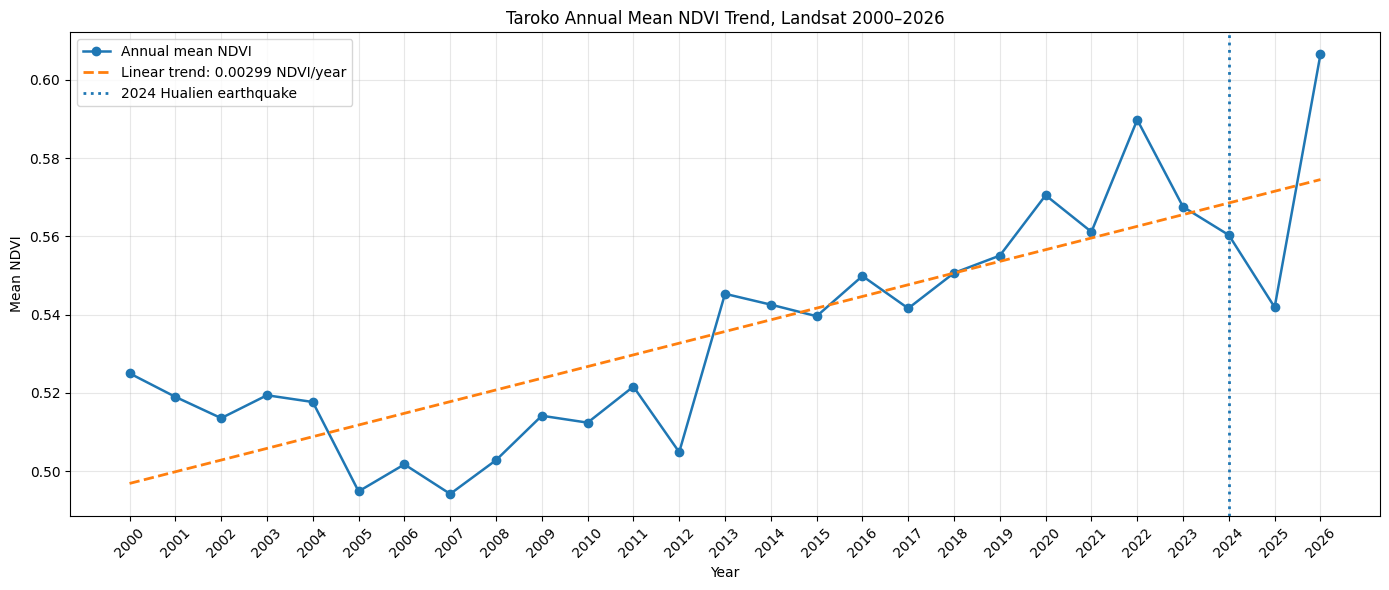

Linear slope: 0.002988 NDVI/year
Approx. 26-year accumulated change: 0.0777


In [13]:
# Load the annual_ndvi_df from Google Drive after the export task completes
import pandas as pd

# Mount Google Drive to access the exported CSV
from google.colab import drive
drive.mount('/content/drive')

# IMPORTANT: Replace 'path/to/your/annual_ndvi_data.csv' with the actual path
# to the CSV file in your Google Drive (e.g., '/content/drive/MyDrive/GEE_Exports/annual_ndvi_data.csv')
file_path = '/content/drive/MyDrive/GEE_Exports/annual_ndvi_data.csv'

try:
    annual_ndvi_df = pd.read_csv(file_path).sort_values('year')
    print(f"Successfully loaded data from: {file_path}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please ensure the Earth Engine export task is complete and the file path is correct.")
    # Exit or handle the error gracefully if the file isn't found
    # For now, we'll raise the error to stop execution
    raise


# Convert to numeric and plot
annual_ndvi_df['year'] = annual_ndvi_df['year'].astype(int)
annual_ndvi_df['NDVI'] = pd.to_numeric(annual_ndvi_df['NDVI'], errors='coerce')

x = annual_ndvi_df['year'].values
y = annual_ndvi_df['NDVI'].values

# Fit trendline using valid years only
valid = np.isfinite(y)
coef = np.polyfit(x[valid], y[valid], 1)
trendline = np.polyval(coef, x)

plt.figure(figsize=(14, 6))
plt.plot(x, y, marker='o', linewidth=1.8, label='Annual mean NDVI')
plt.plot(x, trendline, linestyle='--', linewidth=2, label=f'Linear trend: {coef[0]:.5f} NDVI/year')
plt.axvline(2024, linestyle=':', linewidth=2, label='2024 Hualien earthquake')

plt.title('Taroko Annual Mean NDVI Trend, Landsat 2000–2026')
plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.xticks(x, rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('task1_taroko_ndvi_26yr_trend.png', dpi=200)
plt.show()

print(f"Linear slope: {coef[0]:.6f} NDVI/year")
print(f"Approx. 26-year accumulated change: {coef[0] * (END_YEAR - START_YEAR):.4f}")

## Task 1 Analysis


1. **Long-term trend:** 線性斜率為正，代表 2000–2026 整體偏向 greening。  
2. **Anomalous years:** 年度 NDVI 明顯低於趨勢線的年份，可視為擾動候選年，需對照颱風、豪雨、地震或資料雲量不足等因素。  
3. **Data depth:** Landsat 使用 2000–2026 的多衛星長期資料，時間深度遠高於 W13 Sentinel-2 的 2020–2026，但空間解析度從 10 m 降為 30 m。

# Task 2 — Pixel-Level Linear Trend Analysis

目標：對每個像素建立年度 NDVI 中值影像，使用 `ee.Reducer.linearFit()` 計算 2000–2026 的像素級 NDVI 斜率，並統計 greening / browning / stable 比例。

In [14]:
def annual_ndvi_image(year):
    """Create an annual median NDVI image with a time band."""
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    median_ndvi = ndvi_collection.filterDate(start, end).median().rename('NDVI')
    time_band = ee.Image.constant(year).float().rename('time')

    return (
        median_ndvi
        .addBands(time_band)
        .set('system:time_start', start.millis())
        .set('year', year)
    )


annual_col = ee.ImageCollection(year_list.map(lambda y: annual_ndvi_image(y)))

# linearFit: dependent = NDVI, independent = time
trend = annual_col.select(['time', 'NDVI']).reduce(ee.Reducer.linearFit())
slope = trend.select('scale').rename('NDVI_slope')
offset = trend.select('offset').rename('NDVI_offset')

print("Trend image bands:", trend.bandNames().getInfo())

Trend image bands: ['scale', 'offset']


In [15]:
# Visualize slope map
Map = geemap.Map(center=[24.20, 121.60], zoom=10)
Map.add_basemap('HYBRID')

slope_vis = {
    'min': -0.005,
    'max': 0.005,
    'palette': ['8c510a', 'd8b365', 'f6e8c3', 'c7eae5', '5ab4ac', '01665e']
}

Map.addLayer(slope.clip(aoi), slope_vis, 'NDVI slope 2000–2026')
Map.addLayer(ee.Image().paint(aoi, 1, 2), {'palette': ['yellow']}, 'AOI boundary')
Map.add_colorbar(slope_vis, label='NDVI slope per year')
Map

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [16]:
# Classify trend types
# Thresholds:
# slope > 0.001  : greening
# slope < -0.001 : browning
# otherwise      : stable

greening = slope.gt(0.001).rename('greening')
browning = slope.lt(-0.001).rename('browning')
stable = slope.gte(-0.001).And(slope.lte(0.001)).rename('stable')

classes = (
    ee.Image(0)
    .where(browning, 1)
    .where(stable, 2)
    .where(greening, 3)
    .rename('trend_class')
    .clip(aoi)
)

hist = classes.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).get('trend_class').getInfo()

hist

{'1': 91984.85490196082, '2': 263551.18823529506, '3': 1816774.5607842964}

In [17]:
# Convert histogram to percentage table
class_name = {
    '1': 'Browning (slope < -0.001)',
    '2': 'Stable (-0.001 ≤ slope ≤ 0.001)',
    '3': 'Greening (slope > 0.001)'
}

total_pixels = sum(hist.values())
trend_stats = []

for k, v in sorted(hist.items(), key=lambda item: int(float(item[0]))):
    key = str(int(float(k)))
    trend_stats.append({
        'class': class_name.get(key, key),
        'pixels': v,
        'percentage': v / total_pixels * 100
    })

trend_stats_df = pd.DataFrame(trend_stats)
trend_stats_df

,class,pixels,percentage
0,Browning (slope < -0.001),9.198485e+04,4.234425
1,Stable (-0.001 ≤ slope ≤ 0.001),2.635512e+05,12.132298
2,Greening (slope > 0.001),1.816775e+06,83.633278


In [18]:
# Display trend class map
Map2 = geemap.Map(center=[24.20, 121.60], zoom=10)
Map2.add_basemap('HYBRID')

class_vis = {
    'min': 1,
    'max': 3,
    'palette': ['a6611a', 'ffffbf', '018571']
}

Map2.addLayer(classes, class_vis, 'Trend class: browning / stable / greening')
Map2.addLayer(ee.Image().paint(aoi, 1, 2), {'palette': ['yellow']}, 'AOI boundary')
Map2

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [19]:
# Export trend map as GeoTIFF to Google Drive
# 執行後請到 Earth Engine Tasks 或 Colab 輸出確認任務狀態，並在 Google Drive 截圖作為作業附件。

trend_export = trend.rename(['NDVI_slope', 'NDVI_offset']).clip(aoi)

task = ee.batch.Export.image.toDrive(
    image=trend_export,
    description='taroko_ndvi_trend_26yr',
    folder='GEE_Exports',
    fileNamePrefix='taroko_ndvi_trend_26yr',
    region=aoi,
    scale=30,
    crs='EPSG:32651',
    maxPixels=1e9
)

task.start()
print("Export task started: taroko_ndvi_trend_26yr")
print("Check GEE Tasks / Google Drive folder: GEE_Exports")

Export task started: taroko_ndvi_trend_26yr
Check GEE Tasks / Google Drive folder: GEE_Exports


## Task 2 Discussion: W13 vs W14

W13 使用 Sentinel-2 進行 2020–2026 的 6 年趨勢分析，優點是 10 m 空間解析度較高，能看見較細的崩塌地、道路邊坡與溪谷變化；但 6 年時間窗容易受單一事件、雲量、季節差異影響。W14 使用 Landsat 2000–2026 的 26 年資料，解析度降低為 30 m，但能判斷一個區域是否長期 greening、browning 或穩定。若某區在 2020–2026 呈現 browning，但 2000–2026 slope 仍為正，可能表示它只是短期受災，長期仍具恢復力；反之，若 26 年 slope 為負，則代表較結構性的退化訊號。

# Task 3 — Taoyuan Pond Disappearance with MNDWI

目標：使用 Landsat MNDWI 分析桃園台地 2000–2026 水體出現頻率，並比較早期與近期水體差異，以估算埤塘消失與新增水體面積。

In [20]:
# Taoyuan Plateau AOIs
TAOYUAN_BBOX = [120.94, 24.83, 121.35, 25.08]
TAOYUAN_URBAN_BBOX = [121.00, 24.88, 121.28, 25.05]

aoi_taoyuan = ee.Geometry.Rectangle(TAOYUAN_BBOX)
aoi_taoyuan_urban = ee.Geometry.Rectangle(TAOYUAN_URBAN_BBOX)

landsat_taoyuan = load_landsat_collection(aoi_taoyuan)

print("Taoyuan Landsat images:", landsat_taoyuan.size().getInfo())

Taoyuan Landsat images: 2500


In [21]:
def compute_mndwi(image):
    """MNDWI = (Green - SWIR1) / (Green + SWIR1)."""
    mndwi = image.normalizedDifference(['Green', 'SWIR1']).rename('MNDWI')
    return mndwi.copyProperties(image, ['system:time_start'])


mndwi_taoyuan = landsat_taoyuan.map(compute_mndwi)


def yearly_water(year, threshold=0.1):
    """Annual water mask using MNDWI threshold."""
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    median_mndwi = mndwi_taoyuan.filterDate(start, end).median()
    water = median_mndwi.gt(threshold).rename('water')

    return water.set('system:time_start', start.millis()).set('year', year)


water_col = ee.ImageCollection(year_list.map(lambda y: yearly_water(y, 0.1)))
water_freq = water_col.mean().rename('water_frequency').clip(aoi_taoyuan)

print("Water frequency image ready.")

Water frequency image ready.


In [22]:
# Water frequency map
Map3 = geemap.Map(center=[24.96, 121.15], zoom=10)
Map3.add_basemap('HYBRID')

water_freq_vis = {
    'min': 0,
    'max': 1,
    'palette': ['ffffff', 'c6dbef', '6baed6', '2171b5', '08306b']
}

Map3.addLayer(water_freq, water_freq_vis, 'Water frequency 2000–2026')
Map3.addLayer(ee.Image().paint(aoi_taoyuan, 1, 2), {'palette': ['yellow']}, 'Taoyuan AOI')
Map3.add_colorbar(water_freq_vis, label='Water occurrence probability')
Map3

Map(center=[24.96, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [23]:
# Compare early vs recent periods
early_water = (
    mndwi_taoyuan
    .filterDate('2000-01-01', '2005-12-31')
    .median()
    .gt(0.1)
    .rename('early_water')
    .clip(aoi_taoyuan)
)

recent_water = (
    mndwi_taoyuan
    .filterDate('2021-01-01', '2026-12-31')
    .median()
    .gt(0.1)
    .rename('recent_water')
    .clip(aoi_taoyuan)
)

lost_ponds = early_water.And(recent_water.Not()).rename('lost_ponds')
new_water = recent_water.And(early_water.Not()).rename('new_water')

pond_change_class = (
    ee.Image(0)
    .where(lost_ponds, 1)
    .where(new_water, 2)
    .rename('pond_change')
    .clip(aoi_taoyuan)
)

print("Pond change layers ready.")

Pond change layers ready.


In [25]:
# Estimate area in hectares
pixel_area = ee.Image.pixelArea()

lost_area_m2 = (
    lost_ponds.multiply(pixel_area)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi_taoyuan,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    .get('lost_ponds')
)

new_area_m2 = (
    new_water.multiply(pixel_area)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi_taoyuan,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    .get('new_water')
)

lost_area_ha = ee.Number(lost_area_m2).divide(10000).getInfo()
new_area_ha = ee.Number(new_area_m2).divide(10000).getInfo()
net_change_ha = new_area_ha - lost_area_ha

pond_area_df = pd.DataFrame([{
    'lost_pond_area_ha': lost_area_ha,
    'new_water_area_ha': new_area_ha,
    'net_change_ha': net_change_ha
}])

pond_area_df

Earth Engine export task 'taoyuan_pond_area_change_export' started.
Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.
Once the task is complete, you will need to download the CSV and load it into a Pandas DataFrame manually.
For example, using: pd.read_csv('/path/to/your/taoyuan_pond_area_change.csv')


In [26]:
# Pond change map
Map4 = geemap.Map(center=[24.96, 121.15], zoom=10)
Map4.add_basemap('HYBRID')

change_vis = {
    'min': 1,
    'max': 2,
    'palette': ['red', 'lime']
}

Map4.addLayer(pond_change_class.selfMask(), change_vis, 'Lost ponds = red; new water = green')
Map4.addLayer(ee.Image().paint(aoi_taoyuan_urban, 1, 2), {'palette': ['yellow']}, 'Urbanization corridor')
Map4

Map(center=[24.96, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Task 3 Verification: 223 Known Ponds

老師提供 223 口已知埤塘中心點。下載 GeoJSON，轉為 Earth Engine FeatureCollection，並使用近期 MNDWI 水體圖估算偵測率。


In [27]:
# Download known pond points
# 若環境無法下載，請手動上傳 taoyuan_ponds_223.geojson
!pip install -q gdown

import json
import os
import gdown

pond_geojson_path = 'taoyuan_ponds_223.geojson'

if not os.path.exists(pond_geojson_path):
    gdown.download(
        'https://drive.google.com/uc?id=1qwrIIELIJXbrBL_oCBTcoE-aoWq1bdXw',
        pond_geojson_path,
        quiet=False
    )

with open(pond_geojson_path, encoding='utf-8') as f:
    ponds_geojson = json.load(f)

pond_features = []
for feat in ponds_geojson['features']:
    coords = feat['geometry']['coordinates']
    pond_features.append(ee.Feature(ee.Geometry.Point(coords)))

ponds_fc = ee.FeatureCollection(pond_features)
print("Loaded known pond locations:", len(pond_features))

Downloading...
From: https://drive.google.com/uc?id=1qwrIIELIJXbrBL_oCBTcoE-aoWq1bdXw
To: /content/taoyuan_ponds_223.geojson
100%|██████████| 49.7k/49.7k [00:00<00:00, 9.08MB/s]

Loaded known pond locations: 223


In [28]:
# Detection rate using recent water map
mndwi_at_ponds = recent_water.unmask(0).sampleRegions(
    collection=ponds_fc,
    scale=30,
    geometries=True
)

detected = mndwi_at_ponds.filter(ee.Filter.eq('recent_water', 1)).size()
total = ponds_fc.size()

total_count = total.getInfo()
detected_count = detected.getInfo()
detection_rate = detected_count / total_count * 100

verification_df = pd.DataFrame([{
    'known_ponds': total_count,
    'mndwi_detected': detected_count,
    'detection_rate_percent': detection_rate
}])

verification_df

,known_ponds,mndwi_detected,detection_rate_percent
0,223,195,87.443946


In [29]:
# Optional: display known ponds over recent water
Map5 = geemap.Map(center=[24.96, 121.15], zoom=10)
Map5.add_basemap('HYBRID')
Map5.addLayer(recent_water.selfMask(), {'palette': ['blue']}, 'Recent MNDWI water')
Map5.addLayer(ponds_fc, {'color': 'yellow'}, 'Known pond points')
Map5

Map(center=[24.96, 121.15], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

## Task 3 Analysis

1. **Detection rate:** MNDWI > 0.1 對大型、開闊水面效果較好；未偵測到的埤塘可能面積小於 Landsat 30 m pixel、被植被或浮萍覆蓋、季節性乾涸，或與建物陰影混淆。  
2. **Flood resilience:** 埤塘消失可能降低地表滯洪與蓄水能力，使都市暴雨逕流更集中，增加低窪地區積淹水風險。

# Task 4 — Vegetation Resilience Metrics + Summary

目標：以 2024 地震為衝擊事件，計算 Baseline、Impact、Recovery 三期 NDVI，並建立 Recovery Ratio 圖。

In [30]:
# Baseline period: 2020–2023
baseline_ndvi = (
    ndvi_collection
    .filterDate('2020-01-01', '2023-12-31')
    .median()
    .rename('baseline_ndvi')
)

# Impact period: 2024
impact_ndvi = (
    ndvi_collection
    .filterDate('2024-01-01', '2024-12-31')
    .median()
    .rename('impact_ndvi')
)

# Recovery period: 2025–2026
recovery_ndvi = (
    ndvi_collection
    .filterDate('2025-01-01', '2026-12-31')
    .median()
    .rename('recovery_ndvi')
)

numerator = recovery_ndvi.subtract(impact_ndvi)
denominator = baseline_ndvi.subtract(impact_ndvi)

# Mask pixels where damage signal is too small or denominator is near zero
damage_mask = denominator.abs().gt(0.05)

recovery_ratio = (
    numerator.divide(denominator)
    .updateMask(damage_mask)
    .rename('recovery_ratio')
    .clamp(-1, 2)
    .clip(aoi)
)

print("Recovery ratio image ready.")

Recovery ratio image ready.


In [31]:
# Visualize recovery ratio
Map6 = geemap.Map(center=[24.20, 121.60], zoom=10)
Map6.add_basemap('HYBRID')

rr_vis = {
    'min': -1,
    'max': 2,
    'palette': ['8b0000', 'ffcc00', '7fc97f', '1f78b4']
}

Map6.addLayer(recovery_ratio, rr_vis, 'Recovery Ratio')
Map6.addLayer(ee.Image().paint(aoi, 1, 2), {'palette': ['yellow']}, 'AOI boundary')
Map6.add_colorbar(rr_vis, label='Recovery Ratio')
Map6

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [32]:
# Recovery classes:
# 1: degrading        RR < 0
# 2: slow recovery   0 <= RR < 0.5
# 3: recovering      0.5 <= RR < 1.0
# 4: exceeded        RR >= 1.0

rr_class = (
    ee.Image(0)
    .where(recovery_ratio.lt(0), 1)
    .where(recovery_ratio.gte(0).And(recovery_ratio.lt(0.5)), 2)
    .where(recovery_ratio.gte(0.5).And(recovery_ratio.lt(1.0)), 3)
    .where(recovery_ratio.gte(1.0), 4)
    .rename('recovery_class')
    .updateMask(recovery_ratio.mask())
    .clip(aoi)
)

rr_hist = rr_class.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    bestEffort=True
).get('recovery_class').getInfo()

rr_hist

{'1': 76374.97647058823,
 '2': 118940.49803921573,
 '3': 57105.243137254896,
 '4': 100440.47450980387}

In [33]:
rr_class_name = {
    '1': 'Degrading (RR < 0)',
    '2': 'Slow recovery (0 ≤ RR < 0.5)',
    '3': 'Recovering (0.5 ≤ RR < 1.0)',
    '4': 'Exceeded baseline (RR ≥ 1.0)'
}

rr_total = sum(rr_hist.values())
rr_stats = []

for k, v in sorted(rr_hist.items(), key=lambda item: int(float(item[0]))):
    key = str(int(float(k)))
    rr_stats.append({
        'recovery_class': rr_class_name.get(key, key),
        'pixels': v,
        'percentage_of_damaged_pixels': v / rr_total * 100
    })

rr_stats_df = pd.DataFrame(rr_stats)
rr_stats_df

,recovery_class,pixels,percentage_of_damaged_pixels
0,Degrading (RR < 0),76374.976471,21.644482
1,Slow recovery (0 ≤ RR < 0.5),118940.498039,33.707447
2,Recovering (0.5 ≤ RR < 1.0),57105.243137,16.183486
3,Exceeded baseline (RR ≥ 1.0),100440.474510,28.464585


In [34]:
# Display recovery class map
Map7 = geemap.Map(center=[24.20, 121.60], zoom=10)
Map7.add_basemap('HYBRID')

rr_class_vis = {
    'min': 1,
    'max': 4,
    'palette': ['8b0000', 'ffcc00', '7fc97f', '1f78b4']
}

Map7.addLayer(rr_class, rr_class_vis, 'Recovery classes')
Map7.addLayer(ee.Image().paint(aoi, 1, 2), {'palette': ['yellow']}, 'AOI boundary')
Map7

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [35]:
# Export recovery ratio and class map
rr_export = recovery_ratio.addBands(rr_class).clip(aoi)

rr_task = ee.batch.Export.image.toDrive(
    image=rr_export,
    description='taroko_recovery_ratio_2024_eq',
    folder='GEE_Exports',
    fileNamePrefix='taroko_recovery_ratio_2024_eq',
    region=aoi,
    scale=30,
    crs='EPSG:32651',
    maxPixels=1e9
)

rr_task.start()
print("Export task started: taroko_recovery_ratio_2024_eq")

Export task started: taroko_recovery_ratio_2024_eq


## Task 4 Integration Summary Report

本週 ARIA v9.5 將前幾週的單點、單景與短期變遷分析，擴展為跨 26 年的時空韌性監測。W6 的 Kriging 空間內插強調由有限樣點推估連續空間分布，而 W14 的 Landsat 時序則進一步加入時間軸，使分析從「空間圖」變成「時空圖」。W8 的單景 NDVI 能描述某一時刻的植被狀態，W9 的兩期變遷偵測能指出事件前後差異，但 W14 的 26 年 pixel-level trend 讓我們判斷變化究竟是短期擾動、長期退化，或是恢復中的生態演替。W10 與 W13 的 SAR 分析則可補足光學影像在雲雨山區受限的問題，未來可將 SAR backscatter 時序與 Landsat NDVI slope 結合，提高災後監測穩定性。W12 的土地覆蓋分類也可使用 W14 匯出的長期 composite、slope 與 recovery ratio 作為特徵，以建立更具時序意義的分類模型。

相較 W13 使用 Sentinel-2 進行 2020–2026 的 6 年分析，W14 使用 Landsat 2000–2026 的長期資料，能看見短時間窗中不可見的長期 greening 或 browning 趨勢。Sentinel-2 的 10 m 解析度適合分析細小崩塌、河谷與道路邊坡，但 Landsat 的 30 m 解析度犧牲了細節，換取更長的時間深度。若研究問題是災後細部判釋，Sentinel-2 較佳；若要評估世代尺度的土地變化與韌性，Landsat 更適合。

韌性分析顯示，2024 地震造成的 NDVI 下降可透過 baseline、impact 與 recovery 三期比較量化。Recovery ratio 大於 1 的區域代表已恢復甚至超過基線，0 到 1 則代表部分恢復，低於 0 表示仍持續退化。空間上，溪谷、崩塌地與低植被覆蓋區通常較容易呈現低恢復率，而坡面森林若未受到嚴重破壞，可能展現較高恢復力。不過本分析仍受 Landsat 30 m 解析度、L7 SLC-off 條帶、山區雲量與年度有效觀測數影響，因此結果應搭配 Sentinel-2、SAR 與現地資料驗證。

# Bonus 1 — Multi-Index Dashboard: NDVI, MNDWI, NBR

此加分任務同時計算三個指標，觀察植被、水文與擾動訊號是否一致。

In [38]:
def compute_indices(image):
    """Compute NDVI, MNDWI, and NBR for each image."""
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')
    mndwi = image.normalizedDifference(['Green', 'SWIR1']).rename('MNDWI')
    nbr = image.normalizedDifference(['NIR', 'SWIR2']).rename('NBR')
    return ndvi.addBands(mndwi).addBands(nbr).copyProperties(image, ['system:time_start'])


multi_index_col = landsat_all.map(compute_indices)


def annual_multi_index_feature(year):
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    annual_img = multi_index_col.filterDate(start, end).median()

    stats = annual_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )

    return ee.Feature(None, {
        'year': year,
        'NDVI': stats.get('NDVI'),
        'MNDWI': stats.get('MNDWI'),
        'NBR': stats.get('NBR')
    })


multi_index_fc = ee.FeatureCollection(year_list.map(lambda y: annual_multi_index_feature(y)))

# Export the FeatureCollection to Google Drive as a CSV
export_task_multi_index = ee.batch.Export.table.toDrive(
    collection=multi_index_fc,
    description='multi_index_data_export',
    folder='GEE_Exports', # You might want to specify a different folder in your Google Drive
    fileNamePrefix='multi_index_data',
    fileFormat='CSV'
)

export_task_multi_index.start()

print("Earth Engine export task 'multi_index_data_export' started.")
print("Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.")
print("Once the task is complete, you will need to download the CSV and load it into a Pandas DataFrame manually.")
print("For example, using: pd.read_csv('/path/to/your/multi_index_data.csv').sort_values('year')")


Earth Engine export task 'multi_index_data_export' started.
Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.
Once the task is complete, you will need to download the CSV and load it into a Pandas DataFrame manually.
For example, using: pd.read_csv('/path/to/your/multi_index_data.csv').sort_values('year')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded multi-index data from: /content/drive/MyDrive/GEE_Exports/multi_index_data.csv


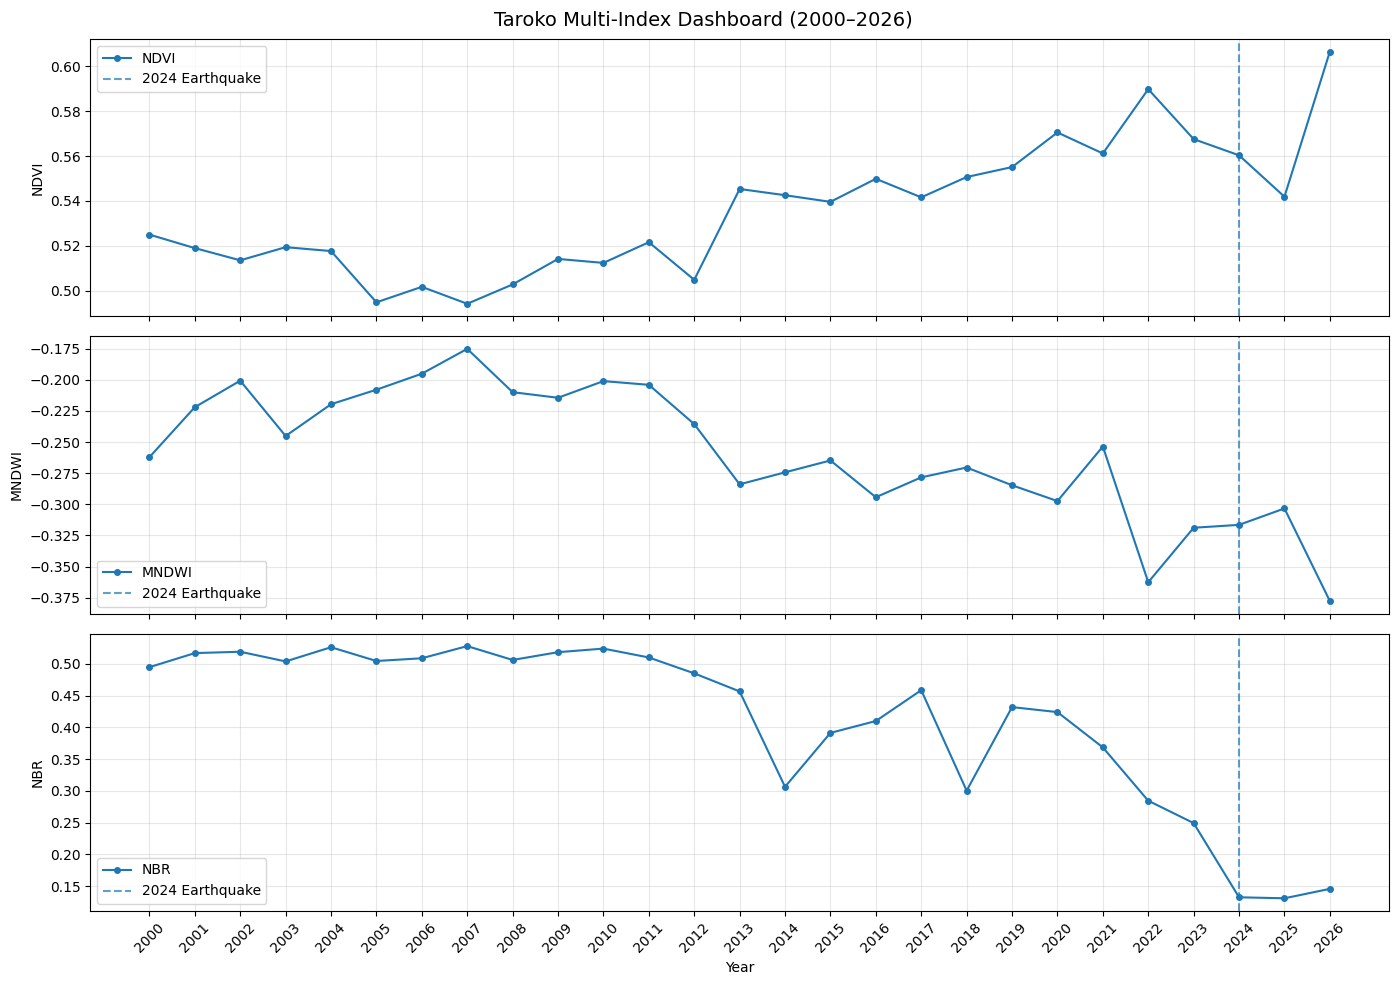

In [42]:
import pandas as pd
from google.colab import drive

# Mount Google Drive to access the exported CSV
drive.mount('/content/drive')

# IMPORTANT: Replace '/path/to/your/multi_index_data.csv' with the actual path
# to the CSV file in your Google Drive (e.g., '/content/drive/MyDrive/GEE_Exports/multi_index_data.csv')
file_path_multi_index = '/content/drive/MyDrive/GEE_Exports/multi_index_data.csv'

try:
    multi_index_df = pd.read_csv(file_path_multi_index).sort_values('year')
    print(f"Successfully loaded multi-index data from: {file_path_multi_index}")
except FileNotFoundError:
    print(f"Error: Multi-index file not found at {file_path_multi_index}. Please ensure the Earth Engine export task is complete and the file path is correct.")
    raise

multi_index_df['year'] = multi_index_df['year'].astype(int)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
indices = ['NDVI', 'MNDWI', 'NBR']

for ax, idx in zip(axes, indices):
    values = pd.to_numeric(multi_index_df[idx], errors='coerce')
    ax.plot(multi_index_df['year'], values, linewidth=1.5, marker='o', markersize=4, label=idx)
    ax.axvline(x=2024, linestyle='--', alpha=0.7, label='2024 Earthquake')
    ax.set_ylabel(idx)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Year')
fig.suptitle('Taroko Multi-Index Dashboard (2000–2026)', fontsize=14)
plt.xticks(multi_index_df['year'], rotation=45)
plt.tight_layout()
plt.savefig('bonus1_multi_index_dashboard.png', dpi=200)
plt.show()

## Bonus 1 Analysis

NDVI 主要反映植被活性，NBR 對火災、裸露地、崩塌與植被結構破壞通常更敏感，MNDWI 則反映水體與濕潤環境。若 2024 年 NDVI 與 NBR 同時下降，較能支持地震或崩塌造成植被與地表結構受損；若 MNDWI 變化明顯，則可能反映河道、湖泊、濕地或陰影水文條件變化。在太魯閣山區，NDVI 適合做整體植被監測，NBR 可作為擾動輔助指標，MNDWI 則不應單獨代表生態韌性。

# Bonus 2 — NDVI Time-Lapse Animation, 2000–2026

此加分任務會透過 Earth Engine thumbnail API 產生每年 NDVI 圖，並組合成 GIF。執行時需要網路連線與 Earth Engine 權限。

In [43]:
# Bonus 2: NDVI time-lapse GIF
# 若不做加分，可跳過此區塊。

import io
import requests
from PIL import Image, ImageDraw
import imageio.v2 as imageio

frames = []
ndvi_palette = ['brown', 'yellow', 'green', 'darkgreen']

for year in YEARS:
    composite = (
        ndvi_collection
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .median()
        .clip(aoi)
    )

    thumb_url = composite.getThumbURL({
        'region': aoi,
        'dimensions': 512,
        'min': 0,
        'max': 0.8,
        'palette': ndvi_palette,
        'format': 'png'
    })

    response = requests.get(thumb_url)
    img = Image.open(io.BytesIO(response.content)).convert('RGB')

    draw = ImageDraw.Draw(img)
    label = str(year)
    if year == 2009:
        label += ' Morakot'
    if year == 2015:
        label += ' Soudelor'
    if year == 2024:
        label += ' Earthquake'

    draw.rectangle([5, 5, 230, 35], fill=(0, 0, 0))
    draw.text((10, 12), label, fill='white')

    frames.append(np.array(img))
    print(year, "OK")

imageio.mimsave(
    'taroko_ndvi_26yr_timelapse.gif',
    frames,
    duration=0.8,
    loop=0
)

print("Saved: taroko_ndvi_26yr_timelapse.gif")

2000 OK
2001 OK
2002 OK
2003 OK
2004 OK
2005 OK
2006 OK
2007 OK
2008 OK
2009 OK
2010 OK
2011 OK
2012 OK
2013 OK
2014 OK
2015 OK
2016 OK
2017 OK
2018 OK
2019 OK
2020 OK
2021 OK
2022 OK
2023 OK
2024 OK
2025 OK
2026 OK
Saved: taroko_ndvi_26yr_timelapse.gif


## Description

若後續年份 NDVI 逐漸回升，代表部分地區具有恢復跡象；若低 NDVI 區域持續存在，則可能代表長期崩塌地或植被恢復困難區。

# Bonus 3 — Landsat × Sentinel-2 Cross-Sensor Change Detection

此加分任務結合 Landsat 30 m 長期趨勢與 Sentinel-2 10 m 細節，進行跨感測器一致性與地震受損區比較。

In [44]:
# Load Sentinel-2 SR Harmonized
# 使用 QA60 + SCL 進行基本雲遮罩

def mask_s2_sr(image):
    scl = image.select('SCL')
    # Remove cloud shadow, clouds, cirrus, snow
    mask = (
        scl.neq(3)
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )
    return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])


def compute_s2_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return ndvi.copyProperties(image, ['system:time_start'])


s2 = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2017-01-01', '2026-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80))
    .map(mask_s2_sr)
    .map(compute_s2_ndvi)
)

print("Sentinel-2 images:", s2.size().getInfo())

Sentinel-2 images: 736


In [50]:
# Landsat vs Sentinel-2 annual NDVI comparison for overlapping years
import pandas as pd
from google.colab import drive

OVERLAP_YEARS = list(range(2017, 2027))
overlap_year_list = ee.List.sequence(2017, 2026)

def cross_sensor_feature(year):
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')

    landsat_median_img = ndvi_collection.filterDate(start, end).median()
    s2_median_img = s2.filterDate(start, end).median()

    landsat_stats = landsat_median_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )

    s2_stats = s2_median_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    )

    # Check if 'NDVI' key exists in the result before getting it
    landsat_mean = ee.Algorithms.If(
        landsat_stats.contains('NDVI'),
        landsat_stats.get('NDVI'),
        None  # Return None if key is not present
    )

    s2_mean = ee.Algorithms.If(
        s2_stats.contains('NDVI'),
        s2_stats.get('NDVI'),
        None  # Return None if key is not present
    )

    return ee.Feature(None, {
        'year': year,
        'Landsat_NDVI': landsat_mean,
        'S2_NDVI': s2_mean
    })


cross_fc = ee.FeatureCollection(overlap_year_list.map(lambda y: cross_sensor_feature(y)))

# Export the FeatureCollection to Google Drive as a CSV.
export_task_cross_sensor = ee.batch.Export.table.toDrive(
    collection=cross_fc,
    description='cross_sensor_data_export',
    folder='GEE_Exports', # You might want to specify a different folder in your Google Drive
    fileNamePrefix='cross_sensor_data',
    fileFormat='CSV'
)

export_task_cross_sensor.start()

print("Earth Engine export task 'cross_sensor_data_export' started.")
print("Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.")
print("Once the task is complete, you will need to run the next cell to load the CSV into a Pandas DataFrame manually.")

Earth Engine export task 'cross_sensor_data_export' started.
Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.
Once the task is complete, you will need to run the next cell to load the CSV into a Pandas DataFrame manually.


In [51]:
import pandas as pd
from google.colab import drive

# Mount Google Drive to access the exported CSV
drive.mount('/content/drive', force_remount=True)

# IMPORTANT: Replace '/path/to/your/cross_sensor_data.csv' with the actual path
# to the CSV file in your Google Drive (e.g., '/content/drive/MyDrive/GEE_Exports/cross_sensor_data.csv')
file_path_cross_sensor = '/content/drive/MyDrive/GEE_Exports/cross_sensor_data.csv'

try:
    cross_df = pd.read_csv(file_path_cross_sensor).sort_values('year')
    print(f"Successfully loaded cross-sensor data from: {file_path_cross_sensor}")
except FileNotFoundError:
    print(f"Error: Cross-sensor file not found at {file_path_cross_sensor}. Please ensure the Earth Engine export task is complete and the file path is correct.")
    # Raise the error to stop execution if the file isn't found.
    raise

cross_df

Mounted at /content/drive
Successfully loaded cross-sensor data from: /content/drive/MyDrive/GEE_Exports/cross_sensor_data.csv


,system:index,Landsat_NDVI,S2_NDVI,year,.geo
0,0,0.541584,NaN,2017.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,0.550636,0.497401,2018.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,0.555073,0.500951,2019.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,0.570498,0.506174,2020.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,0.561140,0.492609,2021.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
5,5,0.589789,0.524720,2022.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
6,6,0.567536,0.512246,2023.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
7,7,0.560317,0.499297,2024.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
8,8,0.541869,0.508840,2025.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
9,9,0.606529,0.492521,2026.0,"{""type"":""MultiPoint"",""coordinates"":[]}"


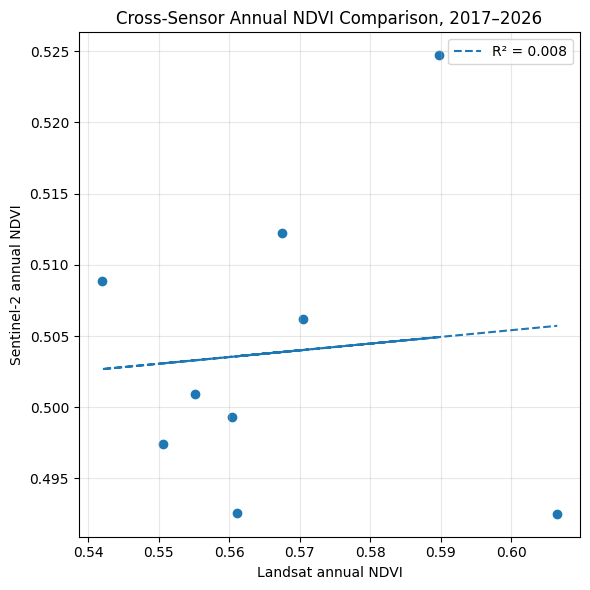

R² = 0.008


In [52]:
# Scatter plot with R²
cross_df['Landsat_NDVI'] = pd.to_numeric(cross_df['Landsat_NDVI'], errors='coerce')
cross_df['S2_NDVI'] = pd.to_numeric(cross_df['S2_NDVI'], errors='coerce')

valid = cross_df[['Landsat_NDVI', 'S2_NDVI']].dropna()
x = valid['Landsat_NDVI'].values
y = valid['S2_NDVI'].values

coef = np.polyfit(x, y, 1)
pred = np.polyval(coef, x)
ss_res = np.sum((y - pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

plt.figure(figsize=(6, 6))
plt.scatter(x, y)
plt.plot(x, pred, linestyle='--', label=f'R² = {r2:.3f}')
plt.xlabel('Landsat annual NDVI')
plt.ylabel('Sentinel-2 annual NDVI')
plt.title('Cross-Sensor Annual NDVI Comparison, 2017–2026')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('bonus3_landsat_s2_ndvi_scatter.png', dpi=200)
plt.show()

print(f"R² = {r2:.3f}")

In [54]:
import pandas as pd

# Earthquake damage comparison: pre vs post
# Landsat 30m
landsat_pre = ndvi_collection.filterDate('2020-01-01', '2024-03-31').median()
landsat_post = ndvi_collection.filterDate('2024-04-01', '2024-12-31').median()
landsat_delta = landsat_post.subtract(landsat_pre).rename('delta_ndvi_landsat')

# Sentinel-2 10m
s2_pre = s2.filterDate('2020-01-01', '2024-03-31').median()
s2_post = s2.filterDate('2024-04-01', '2024-12-31').median()
s2_delta = s2_post.subtract(s2_pre).rename('delta_ndvi_s2')

landsat_damage = landsat_delta.lt(-0.15).rename('damage_landsat')
s2_damage = s2_delta.lt(-0.15).rename('damage_s2')

def calculate_area_ha_ee(mask_img, band_name, scale):
    """Calculates area in hectares as an ee.Number without client-side retrieval."""
    area_m2 = (
        mask_img.multiply(ee.Image.pixelArea())
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=aoi,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        .get(band_name)
    )
    return ee.Number(area_m2).divide(10000)

# Calculate damage areas as ee.Number objects
landsat_damage_area_ee = calculate_area_ha_ee(landsat_damage, 'damage_landsat', 30)
s2_damage_area_ee = calculate_area_ha_ee(s2_damage, 'damage_s2', 10)

# Create a Feature to hold both results
damage_feature = ee.Feature(None, {
    'sensor_landsat': 'Landsat',
    'resolution_landsat_m': 30,
    'damage_area_landsat_ha': landsat_damage_area_ee,
    'sensor_sentinel2': 'Sentinel-2',
    'resolution_sentinel2_m': 10,
    'damage_area_sentinel2_ha': s2_damage_area_ee
})

# Create a FeatureCollection from this single feature
damage_fc = ee.FeatureCollection([damage_feature])

# Export the FeatureCollection to Google Drive as a CSV
export_task_damage_compare = ee.batch.Export.table.toDrive(
    collection=damage_fc,
    description='earthquake_damage_compare_export',
    folder='GEE_Exports', # You might want to specify a different folder in your Google Drive
    fileNamePrefix='earthquake_damage_compare',
    fileFormat='CSV'
)

export_task_damage_compare.start()

print("Earth Engine export task 'earthquake_damage_compare_export' started.")
print("Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.")
print("Once the task is complete, you will need to load the CSV into a Pandas DataFrame manually.")
print("For example, using: pd.read_csv('/content/drive/MyDrive/GEE_Exports/earthquake_damage_compare.csv')")


Earth Engine export task 'earthquake_damage_compare_export' started.
Please check your Earth Engine Tasks tab (link: https://code.earthengine.google.com/tasks) or Google Drive folder 'GEE_Exports' for the exported CSV file.
Once the task is complete, you will need to load the CSV into a Pandas DataFrame manually.
For example, using: pd.read_csv('/content/drive/MyDrive/GEE_Exports/earthquake_damage_compare.csv')


In [55]:
# Multi-resolution damage map
Map8 = geemap.Map(center=[24.20, 121.60], zoom=10)
Map8.add_basemap('HYBRID')
Map8.addLayer(landsat_damage.selfMask().clip(aoi), {'palette': ['orange']}, 'Landsat damage ΔNDVI < -0.15')
Map8.addLayer(s2_damage.selfMask().clip(aoi), {'palette': ['red']}, 'S2 damage ΔNDVI < -0.15')
Map8.addLayer(ee.Image().paint(aoi, 1, 2), {'palette': ['yellow']}, 'AOI boundary')
Map8

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Bonus 3 Methodology Reflection

Landsat 適合用於長期趨勢、世代尺度土地變化、災害前後歷史脈絡與韌性分析，因為它提供自 1980 年代以來連續且一致的觀測紀錄。Sentinel-2 則適合用於近年高解析度變遷偵測，例如地震崩塌地、道路邊坡、溪谷沖刷與小尺度土地覆蓋變化。兩者的差異可視為「望遠鏡與顯微鏡」：Landsat 先定位長期 browning hotspot 或異常趨勢區，Sentinel-2 再進入熱區判讀細節。未來研究可先以 Landsat 建立 20 年以上背景趨勢，再以 Sentinel-2 或 SAR 驗證近年事件，結合時間深度與空間細節。

# Short Reflection

26 年 Landsat 分析與 6 年 Sentinel-2 分析最大的差異在於時間尺度。6 年資料能清楚描述近年事件，例如 2024 地震前後的植被變化，但容易受到單一災害、季節與雲量影響；26 年資料則能判斷這些變化是否只是短期波動，或是長期退化趨勢的一部分。「韌性」在防災管理中重要，因為災害損失只是第一個問題，真正影響土地管理的是受損後能否恢復、恢復速度多快，以及哪些地區可能長期無法回到原狀。從 W8 到 W14，ARIA 系統從單景指標、兩期差異、分類與雲端時序，逐步演進成能評估長期趨勢與恢復能力的監測框架，顯示遙測分析的價值不只在製圖，而在支援決策。